In [1]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf

import scipy.signal as sp_sig

In [14]:
frequency = 10000         # Hz
FS = 96000               # Hz

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


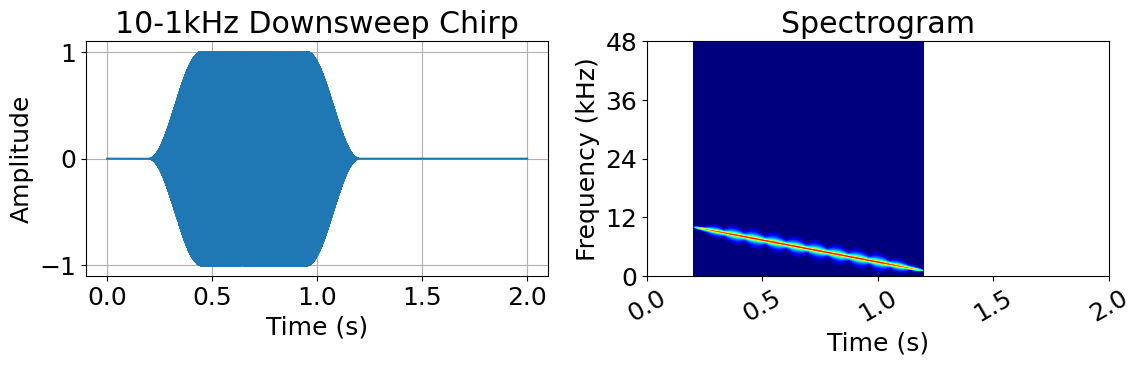

In [15]:
TIME_DURATION = 2
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))
sig_duration = 1
raw_signal = sp_sig.chirp(np.linspace(0, sig_duration, int(FS*sig_duration)), f0=10000, t1=sig_duration, f1=1000)
window_func = sp_sig.windows.tukey(int(FS*sig_duration))

signal = np.zeros(t.size)
time_transmitted = 0.2
signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = raw_signal * window_func

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, signal)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(frequency/1000)}-{int(frequency/10000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(signal, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 5)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [16]:
sf.write(f"test_chirp_bird1s_10kHz_to_1kHz.wav", signal, FS)

/Users/adityakrishna/miniforge3/envs/bat_msds/lib/python3.9/site-packages/matplotlib/axes/_axes.py:8091: RuntimeWarning: divide by zero encountered in log10
  Z = 20. * np.log10(spec)


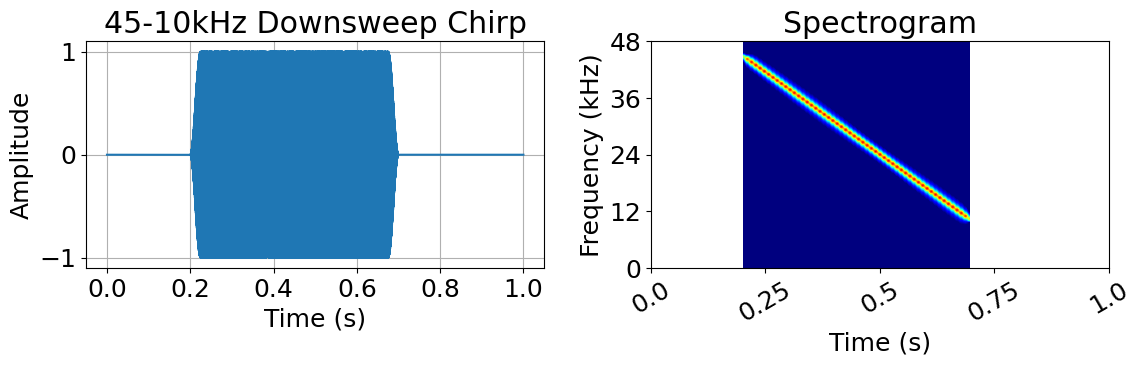

In [25]:
TIME_DURATION = 1
t = np.linspace(0, TIME_DURATION, int(FS*TIME_DURATION))

sig_duration = 0.5
n_chirp = round(FS * sig_duration)
chirp_t = np.arange(n_chirp) / FS

freq0 = 45000
freq1 = 10000
raw_signal = sp_sig.chirp(chirp_t, f0=freq0, t1=sig_duration, f1=freq1, method="linear",)
window = sp_sig.windows.tukey(n_chirp, alpha=0.1)
raw_signal *= window

signal = np.zeros(t.size)
time_transmitted = 0.2
signal[round(FS*time_transmitted):round(FS*(time_transmitted+sig_duration))] = raw_signal

fig, ax_all = plt.subplots(1, 2, figsize=(12, 4))
plt.rcParams.update({'font.size': 18})

ax = ax_all[0]
ax.plot(t, signal)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.set_title(f"{int(freq0/1000)}-{int(freq1/1000)}kHz Downsweep Chirp")
ax.grid(which='both')

vmax = 0
vmin = -100

spec_features = dict()
spec_features['NFFT'] = 1024 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = vmin
spec_features['vmax'] = vmax

vmax = spec_features['vmax']
vmin = spec_features['vmin']
cmap = spec_features['cmap']
nfft = spec_features['NFFT']

ax = ax_all[1]
_, _, _, im = ax.specgram(signal, NFFT=nfft, Fs=FS, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')
ax.set_yticks(ticks=np.arange(0, 48e3+1, 12e3), labels=np.arange(0, 48+1, 12))
ax.set_ylim(0, 48e3)
xticks_sec = np.linspace(0, TIME_DURATION, 5)
xtick_labels_ms = (xticks_sec)

ax.set_xticks(xticks_sec)
ax.set_xticklabels(xtick_labels_ms, rotation=30)
ax.set_ylabel('Frequency (kHz)')
ax.set_xlabel('Time (s)')
ax.set_title(f"Spectrogram")

fig.tight_layout()
plt.show()

In [26]:
sf.write(f"test_chirp_bird1s_{int(freq0/1000)}kHz_to_{int(freq1/1000)}kHz.wav", signal, samplerate=FS, subtype="PCM_24")

In [27]:
info = sf.info(f"test_chirp_bird1s_{int(freq0/1000)}kHz_to_{int(freq1/1000)}kHz.wav")
print(info)

test_chirp_bird1s_45kHz_to_10kHz.wav
samplerate: 96000 Hz
channels: 1
duration: 96000 samples
format: WAV (Microsoft) [WAV]
subtype: Signed 24 bit PCM [PCM_24]


In [24]:
print(sf.info("../../Downloads/20260805_163711.WAV"))

../../Downloads/20260805_163711.WAV
samplerate: 384000 Hz
channels: 1
duration: 9.000 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]
